### 1. Импорты

In [1]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path

### 2. Загрузка данных

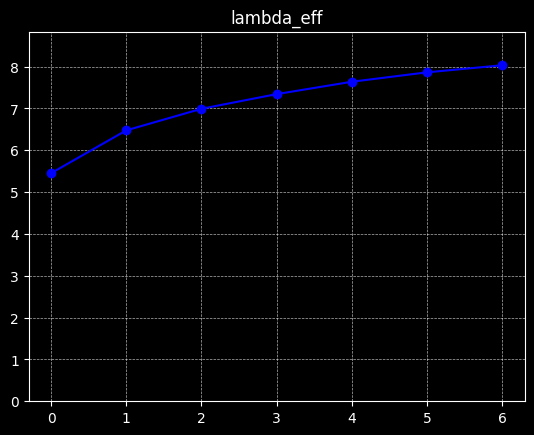

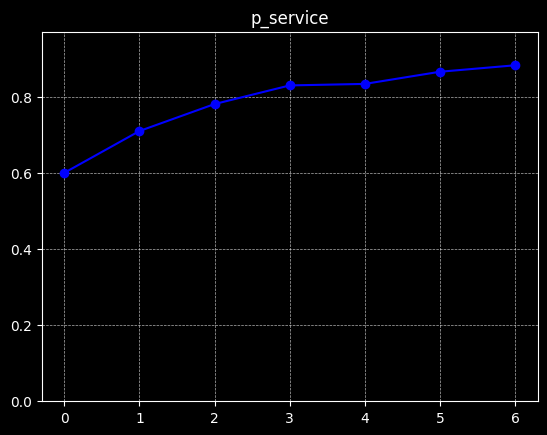

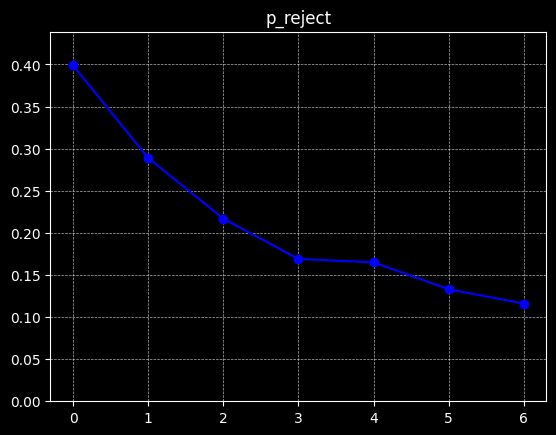

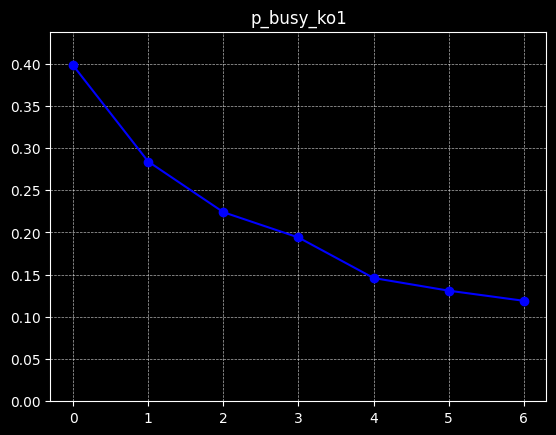

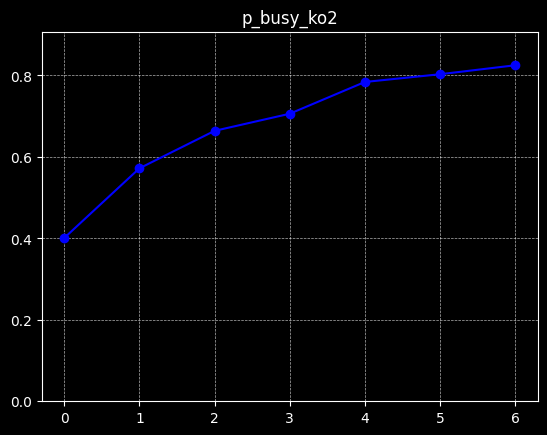

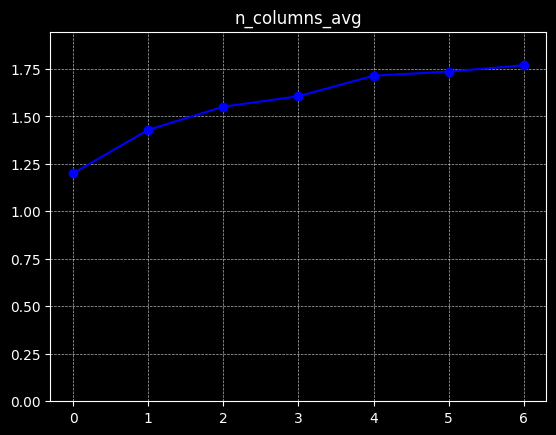

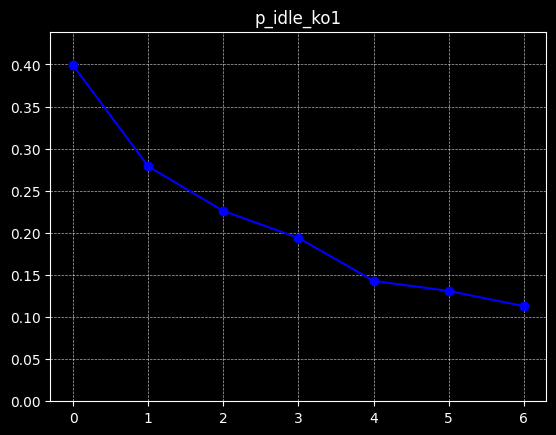

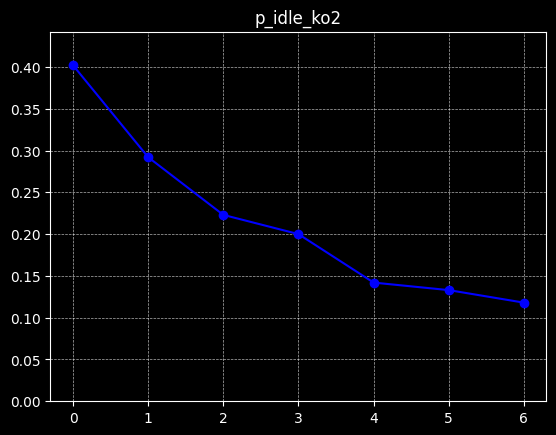

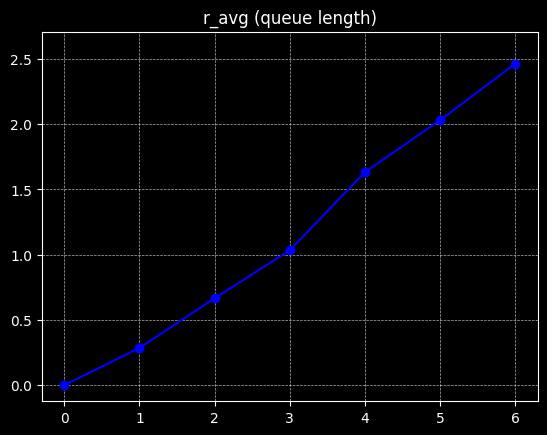

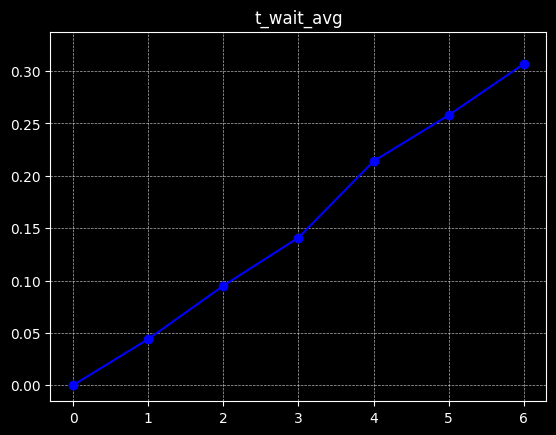

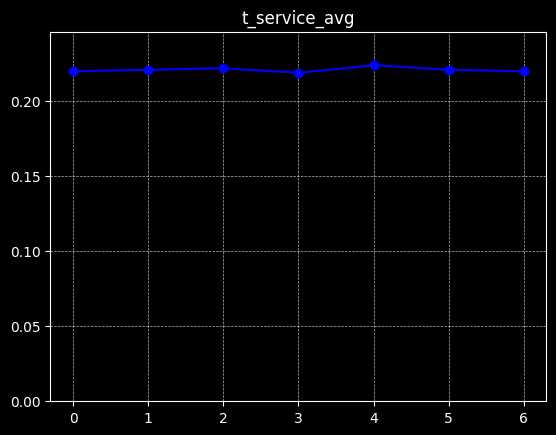

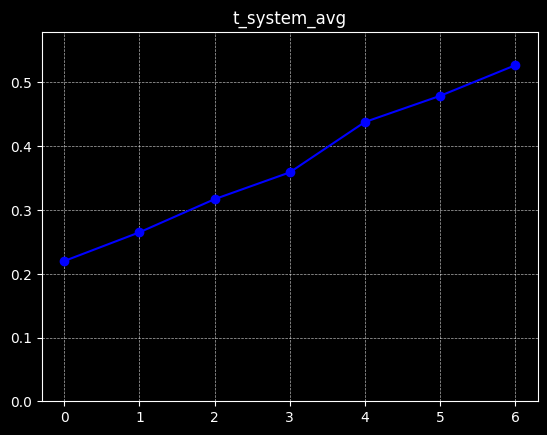

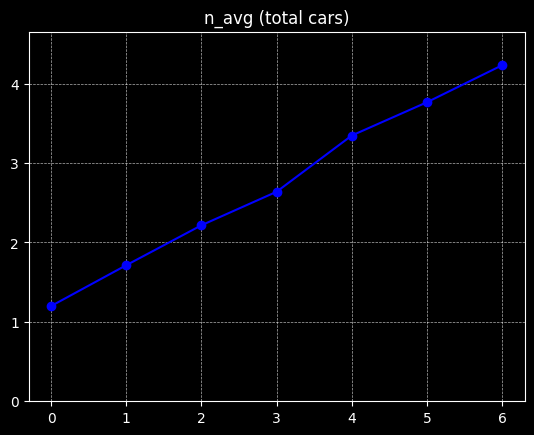

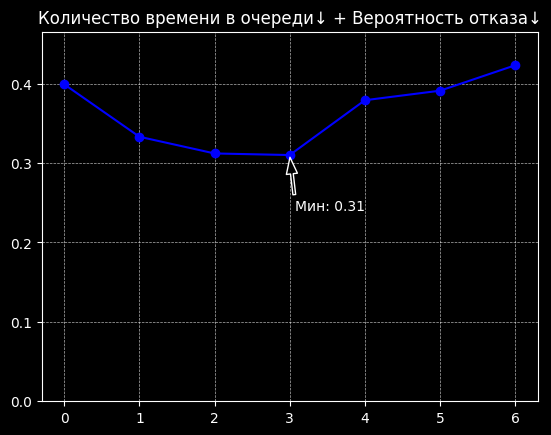

In [41]:
FILENAME = "results.csv"
BASE_DIR = Path.cwd()

def get_data_csv(path):
    if not path.exists():
        print("Файл не найден")
        return []
    try:
        with open(path, "r", newline="") as file:
            reader = csv.reader(file)
            return [*reader]

    except Exception as e:
        print(f"Ошибка работы с файлом {path}. {e}")
        return []
data = {}

path = BASE_DIR / '2_queue_of_car' / 'results_multiple_queues.csv'

data_queue = get_data_csv(path)
for key, *values, _ in data_queue[1:]:
    values = [round(float(i), 3) for i in values]
    data[key] = values


for key, value in data.items():
    figure, axes = plt.subplots()
    axes.plot([0,1,2,3,4,5,6], value, "ob-")
    axes.set_ylim(bottom=min(0,min(value)-max(value) * 0.05), top=max(value) * 1.1)
    axes.grid(True, which="major", axis="both", linestyle="--", linewidth=0.5, alpha=0.7)
    axes.set_xticks([0,1,2,3,4,5,6])
    plt.title(key)
    plt.show()


figure, axes = plt.subplots()
title = "Количество времени в очереди↓ + Вероятность отказа↓"
data[title] = [data["t_wait_avg"][i] + data["p_reject"][i] for i in range(len(data["t_wait_avg"]))]
min_val = min(data[title])
min_idx = data[title].index(min_val)
axes.plot([0,1,2,3,4,5,6], data[title], "ob-")
axes.set_ylim(bottom=min(0,min(data[title])-max(data[title]) * 0.05), top=max(data[title]) * 1.1)
axes.grid(True, which="major", axis="both", linestyle="--", linewidth=0.5, alpha=0.7)
axes.set_xticks([0,1,2,3,4,5,6])
plt.title(title)
# Используем annotate вместо text
axes.annotate(
    f"Мин: {min_val}",
    xy=(min_idx, min_val),          # Куда указывает стрелка (координаты точки)
    xytext=(min_idx + 1.0, min_val - 0.07), # Где расположить текст
    arrowprops=dict(
        facecolor="black",          # Цвет заливки стрелки
        shrink=0.05,                # Отступ стрелки от точки и текста
        width=2,                    # Ширина самой стрелки
        headwidth=8                 # Ширина наконечника
    ),
    horizontalalignment="right"     # Выравнивание текста относительно его координат
)

plt.show()